## Student Performance Analyser
#### 1. Problem Stat: how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

## Importing the csv Data:

In [4]:
df = pd.read_csv("data/stud.csv")
print(df.head())

   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [5]:
# Checkinh=g  duplicates
print(df.duplicated().sum())  # Algo to remove duplicates-> df.drop_duplicates(inplace=True)

0


In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [7]:
df.shape

(1000, 8)

In [8]:
# Checking the null values
print(df.isnull().sum())

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64


In [9]:
# Checking the unique values in each column  --> Df has no attribute unique(always use nunique)
print(df.nunique())

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64


In [10]:
# Exploring the Data (Unique values in each column):
print(df['gender'].unique())
print(df['race_ethnicity'].unique())
print(df['parental_level_of_education'].unique())
print(df['lunch'].unique())
print(df['test_preparation_course'].unique())
print(df['math_score'].unique())
print(df['reading_score'].unique())
print(df['writing_score'].unique())


['female' 'male']
['group B' 'group C' 'group A' 'group D' 'group E']
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
['standard' 'free/reduced']
['none' 'completed']
[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96  24  29  40]
[ 74  88  93  44  75  78  92  39  67  50  52  43  73  70  58  86  28  46
  61  63  53  80  72  55  65  38  82  79  83  59  57  54  68  66  62  76
  

## Finding Numerical and Ctaegorical features 
#### The num values are converted into cat by storig the dtype in objects bcz -->  In Pandas, all text/string/word columns are stored as object dtype — so always use == 'object' to find categorical columns

In [11]:
# Defining the numerical and categorical features:  # Converting them into objects
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'object']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'object']

print("Numerical features:", numerical_features) 
print("Categorical features:", categorical_features) # None values in cat features bcz after converting numerical --> int --> 0 and categorical

Numerical features: ['math_score', 'reading_score', 'writing_score']
Categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [12]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
# Finding the total score and average score of each student
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
# How many students have completed the test preparation course?
print(df['test_preparation_course'].value_counts())

test_preparation_course
none         642
completed    358
Name: count, dtype: int64


In [15]:
# How many students have scored full marks in math, reading and writing?
print('No of studets scored full in maths:',df[df['math_score']==100].shape[0])  # 7
print('No of studnets scored full in reading:',df[df['reading_score']==100].shape[0]) # 17
print('No of students scored full in writing:',df[df['writing_score']==100].shape[0])  # 14

No of studets scored full in maths: 7
No of studnets scored full in reading: 17
No of students scored full in writing: 14


In [16]:
# Marks less than 20:
print("No of students scored less than 20 in maths:",df [df['math_score']<=20]['average_score'].shape[0])
print("No of students scored less than 20 in reading:",df [df['reading_score']<=20]['average_score'].shape[0])
print("No of students scored less than 20 in writing:",df[df['writing_score']<=20]['average_score'].shape[0])

No of students scored less than 20 in maths: 4
No of students scored less than 20 in reading: 1
No of students scored less than 20 in writing: 3


## Insights :
#### Students are weak in maths and have a good knowledge in reading section


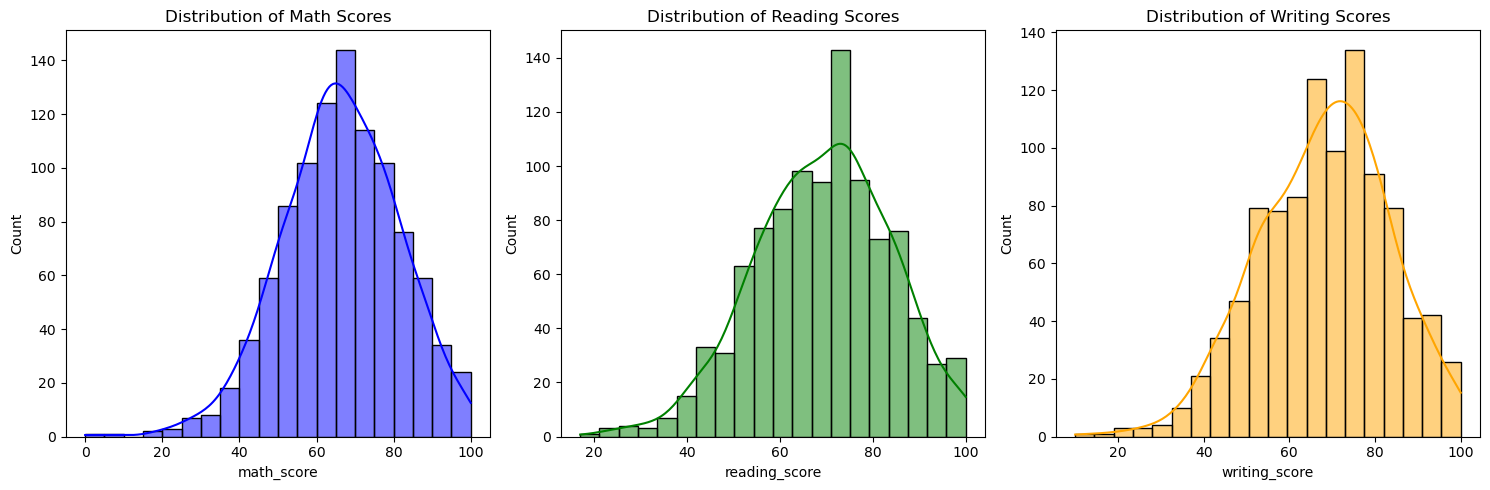

In [17]:
# Visulaizing through Histogram: Understading the distribution of marks in each subject
fig, axs = plt.subplots(1,3, figsize=(15,5))
plt.subplot(1,3,1)
sns.histplot(df['math_score'], bins=20, kde=True, color='blue', ax=axs[0])
axs[0].set_title('Distribution of Math Scores')
plt.subplot(1,3,2)
sns.histplot(df['reading_score'], bins=20, kde=True, color='green', ax=axs[1])
axs[1].set_title('Distribution of Reading Scores')
plt.subplot(1,3,3)
axs[2].set_title('Distribution of Writing Scores')
sns.histplot(df['writing_score'], bins=20, kde=True, color='orange', ax=axs[2])
plt.tight_layout()
plt.show()



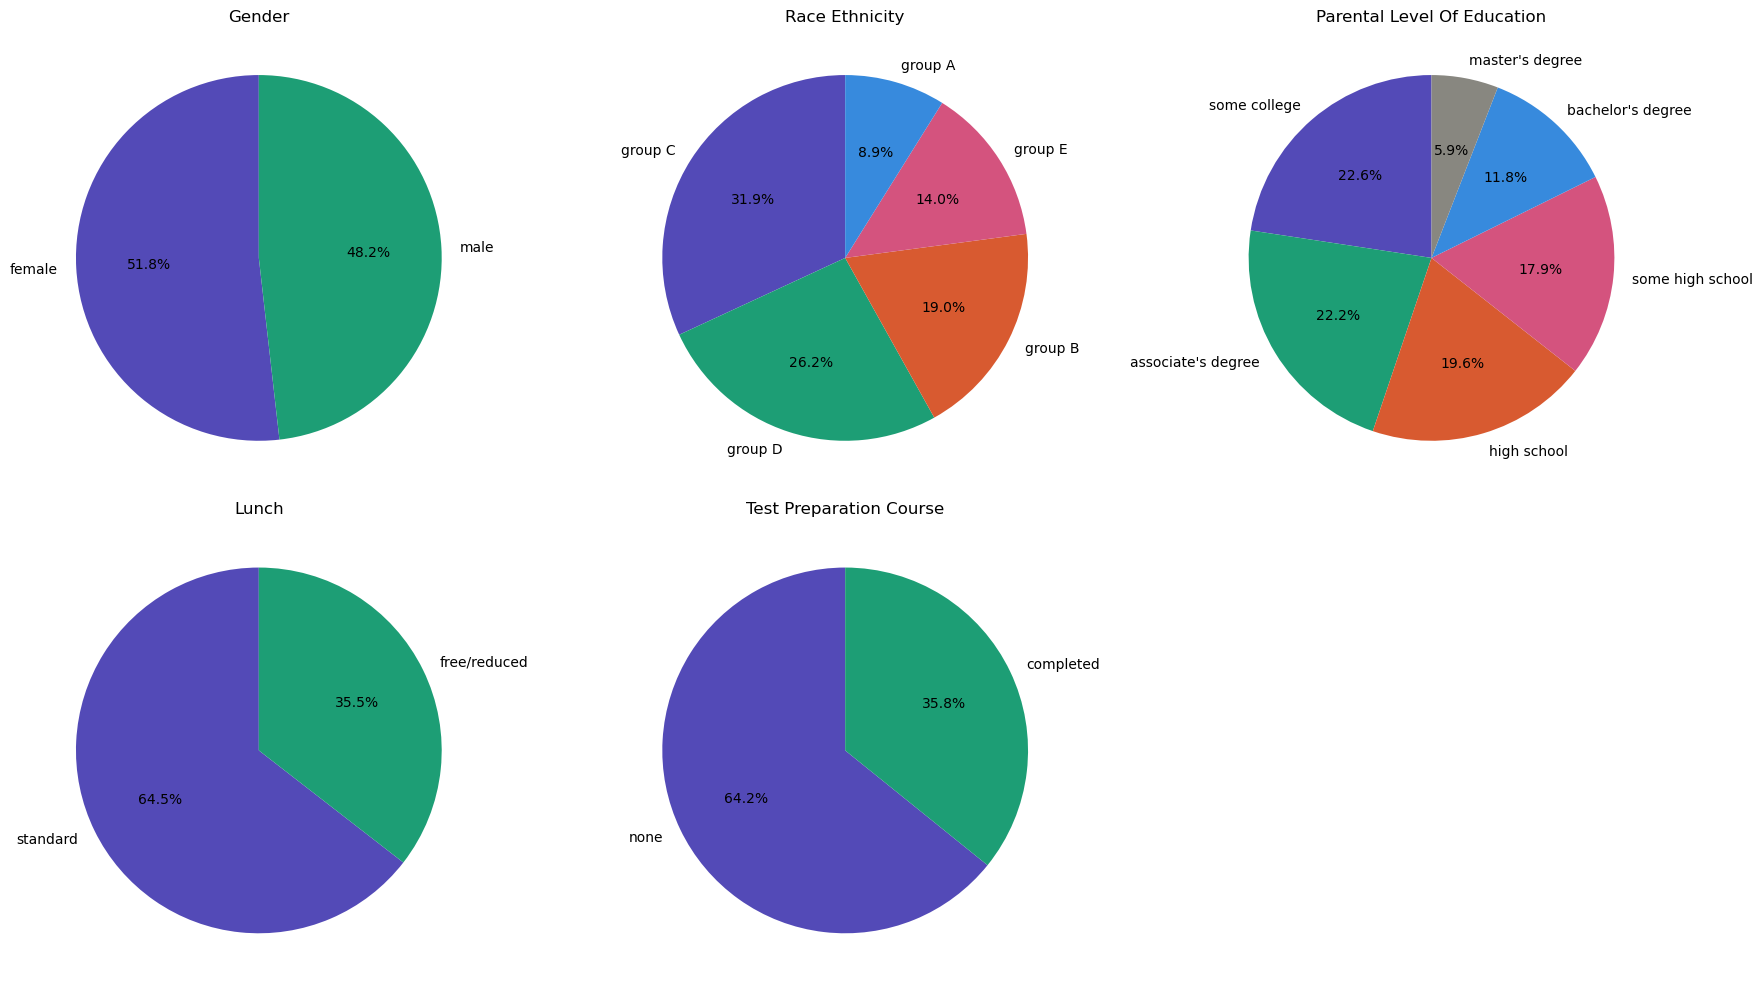

In [18]:
# Visualizing through Circle Plot: Understanding the distribution of students based on their parental level of education
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()

colors = ['#534AB7','#1D9E75','#D85A30','#D4537E','#378ADD','#888780']

for i, col in enumerate(categorical_features):
    counts = df[col].value_counts()
    axs[i].pie(counts, 
               labels=counts.index, 
               autopct='%1.1f%%',    # Shows percentage
               colors=colors[:len(counts)],
               startangle=90)
    axs[i].set_title(col.replace('_', ' ').title())

axs[5].axis('off')   # Hide empty 6th plot
plt.tight_layout()
plt.show()